# Aerodynamic Coefficient Identification from Flight Data

This notebook identifies the lift and drag coefficients ($C_L$, $C_D$) from experimental flight data by analyzing the relationship between:
- Angle of attack (α)
- Flight speed (V)
- Motor RPM (thrust proxy)

The approach uses force balance equations in steady-level flight to extract aerodynamic coefficients.

In [111]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

# Set up paths
base_path = Path('..')
data_path = base_path / 'data'
output_dir = data_path / 'aerodynamic_analysis'
output_dir.mkdir(exist_ok=True)

print("Setup complete")

Setup complete


## 1. Define Platform Parameters

Physical constants and platform specifications needed for coefficient estimation.

In [112]:
# Platform parameters
mass = 2.5  # kg - total vehicle mass
g = 9.81    # m/s^2 - gravitational acceleration
weight = mass * g  # N - vehicle weight

# Wing geometry
wing_span = 0.45     # m - total wingspan
projected_wing_span = wing_span * np.cos(np.radians(45))
wing_chord = 0.25    # m - wing chord length

wing_area = 4 * projected_wing_span * wing_chord  # m^2 - total wing area

# Air properties (standard conditions)
rho = 1.225  # kg/m^3 - air density at sea level

# Thrust model coefficients (from thrust map identification)
# T = k2 * RPM^2 + k1 * RPM (in Newtons)
k2 = 5.15e-6  # N/(RPM^2)
k1 = -0.090e-2   # N/RPM

print(f"Vehicle weight: {weight:.2f} N")
print(f"Wing area: {wing_area:.4f} m²")
print(f"Thrust model: T = {k2:.2e} * RPM² + {k1:.3f} * RPM")

Vehicle weight: 24.53 N
Wing area: 0.3182 m²
Thrust model: T = 5.15e-06 * RPM² + -0.001 * RPM


## 2. Input Experimental Data

Manually enter flight data from experiments at different speeds.
For each speed condition, provide:
- Speed (m/s)
- Angle of attack (degrees, from horizontal)
- Average motor RPM during steady flight

In [113]:
# Experimental data - MANUALLY INPUT VALUES HERE
# Each row: [speed (m/s), angle_of_attack (deg), avg_motor_rpm]

flight_data = np.array([
    ## [speed, alpha, motor_rpm]
    # [5.9,  60.5, 1175],  
    [9.14,  37.2, 1130], 
    ## [10.52,  67.6, 1110], # 51.5 deg roll
    [10.67,  28.5, 1110],  # 24.0 deg roll
    ## [11.0,  36.9, 1100], # 57 deg roll 
    [11.4,  22.3, 1050],  # 19.0 deg roll
    ## [12.5,  21.0, 1057],  
    ## [13.6,  17.7, 1084],  
    ## [13.6,  18.6, 1059],  
    ## [13.6,  19.7, 1028],  
    [13.6,  16.3, 997],  
])

# flight_data[:, 1] = 90.0 - flight_data[:, 1]

# Create DataFrame for easier handling
df = pd.DataFrame(flight_data, columns=['speed', 'alpha_deg', 'motor_rpm'])
df['alpha_rad'] = np.deg2rad(df['alpha_deg'])  # Convert to radians

print("Flight data entered:")
print(df)
print(f"\nTotal data points: {len(df)}")

Flight data entered:
   speed  alpha_deg  motor_rpm  alpha_rad
0   9.14       37.2     1130.0   0.649262
1  10.67       28.5     1110.0   0.497419
2  11.40       22.3     1050.0   0.389208
3  13.60       16.3      997.0   0.284489

Total data points: 4


## 3. Calculate Thrust from Motor RPM

Use the thrust map model to estimate total thrust from motor speeds.

In [114]:
def calculate_thrust(rpm):
    """Calculate thrust per motor using quadratic fit."""
    return k2 * rpm**2 + k1 * rpm

# Calculate total thrust (4 motors)
df['thrust_per_motor'] = df['motor_rpm'].apply(calculate_thrust)
df['total_thrust'] = 4 * df['thrust_per_motor']

print("Thrust calculations:")
print(df[['speed', 'motor_rpm', 'thrust_per_motor', 'total_thrust']])

Thrust calculations:
   speed  motor_rpm  thrust_per_motor  total_thrust
0   9.14     1130.0          5.559035     22.236140
1  10.67     1110.0          5.346315     21.385260
2  11.40     1050.0          4.732875     18.931500
3  13.60      997.0          4.221846     16.887385


## 4. Force Balance Equations

For steady-level flight, the force balance gives:

**Vertical equilibrium:**
$$T \cos(\alpha) + L - W = 0$$
$$L = W - T \cos(\alpha)$$

**Horizontal equilibrium:**
$$T \sin(\alpha) - D = 0$$
$$D = T \sin(\alpha)$$

**Aerodynamic coefficients:**
$$C_L = \frac{L}{\frac{1}{2} \rho V^2 S}$$
$$C_D = \frac{D}{\frac{1}{2} \rho V^2 S}$$

In [115]:
# Calculate aerodynamic forces
df['lift'] = weight - df['total_thrust'] * np.cos(df['alpha_rad'])
df['drag'] = df['total_thrust'] * np.sin(df['alpha_rad'])

# Calculate dynamic pressure
df['q'] = 0.5 * rho * df['speed']**2  # N/m^2

# Calculate lift coefficients for different wing area assumptions
wing_area_factors = [0.3, 0.5, 1.0]  # Fractions of full wing area

for factor in wing_area_factors:
    effective_wing_area = wing_area * factor
    df[f'CL_{factor:.1f}'] = df['lift'] / (df['q'] * effective_wing_area)

# Calculate drag coefficient with full wing area only
df['CD'] = df['drag'] / (df['q'] * wing_area)

# Use full wing area for default CL (backward compatibility)
df['CL'] = df['CL_1.0']

# Calculate lift-to-drag ratio
df['L_D_ratio'] = df['lift'] / df['drag']

print("\nAerodynamic coefficients (full wing area):")
print(df[['speed', 'alpha_deg', 'CL', 'CD', 'L_D_ratio']])

print("\nLift coefficients for different wing area assumptions:")
print(df[['speed', 'alpha_deg', 'CL_0.3', 'CL_0.5', 'CL_1.0']])


Aerodynamic coefficients (full wing area):
   speed  alpha_deg        CL        CD  L_D_ratio
0   9.14       37.2  0.418464  0.825716   0.506789
1  10.67       28.5  0.258296  0.459880   0.561660
2  11.40       22.3  0.276737  0.283618   0.975739
3  13.60       16.3  0.230703  0.131484   1.754615

Lift coefficients for different wing area assumptions:
   speed  alpha_deg    CL_0.3    CL_0.5    CL_1.0
0   9.14       37.2  1.394881  0.836928  0.418464
1  10.67       28.5  0.860988  0.516593  0.258296
2  11.40       22.3  0.922456  0.553474  0.276737
3  13.60       16.3  0.769011  0.461407  0.230703


## 5. Visualization: C_L vs α

## 5. Wing Area Sensitivity Analysis

Comparison of lift coefficients calculated with different wing area assumptions (30%, 50%, and 100% of full wing area).

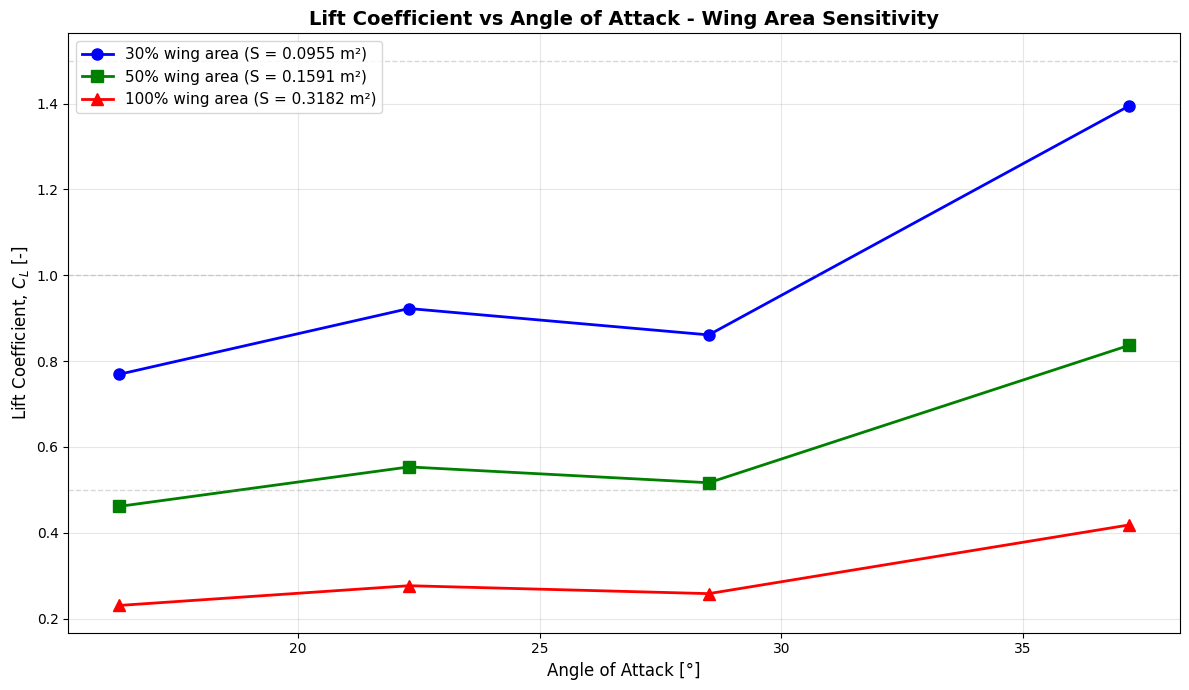

✓ Plot saved to: ../data/aerodynamic_analysis/CL_wing_area_sensitivity.png

Full wing area: 0.3182 m²
30% wing area: 0.0955 m²
50% wing area: 0.1591 m²


In [116]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CL for different wing area assumptions
colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']
wing_area_factors = [0.3, 0.5, 1.0]

for i, factor in enumerate(wing_area_factors):
    effective_area = wing_area * factor
    ax.plot(df['alpha_deg'], df[f'CL_{factor:.1f}'], 
            marker=markers[i], 
            linewidth=2, 
            markersize=8, 
            color=colors[i],
            label=f'{factor*100:.0f}% wing area (S = {effective_area:.4f} m²)')

ax.set_xlabel('Angle of Attack [°]', fontsize=12)
ax.set_ylabel('Lift Coefficient, $C_L$ [-]', fontsize=12)
ax.set_title('Lift Coefficient vs Angle of Attack - Wing Area Sensitivity', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

# Add horizontal reference lines for typical CL ranges
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=1.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig(output_dir / 'CL_wing_area_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to: {output_dir / 'CL_wing_area_sensitivity.png'}")
print(f"\nFull wing area: {wing_area:.4f} m²")
print(f"30% wing area: {wing_area*0.3:.4f} m²")
print(f"50% wing area: {wing_area*0.5:.4f} m²")

In [117]:
# Create comparison table
print("\nDetailed CL Comparison:")
print("="*80)
print(f"{'Speed':<10} {'α':<10} {'CL (30%)':<15} {'CL (50%)':<15} {'CL (100%)':<15}")
print(f"{'[m/s]':<10} {'[deg]':<10} {'[-]':<15} {'[-]':<15} {'[-]':<15}")
print("="*80)
for _, row in df.iterrows():
    print(f"{row['speed']:<10.2f} {row['alpha_deg']:<10.2f} {row['CL_0.3']:<15.4f} {row['CL_0.5']:<15.4f} {row['CL_1.0']:<15.4f}")
print("="*80)

# Calculate statistics
print("\nStatistics:")
for factor in [0.3, 0.5, 1.0]:
    cl_col = f'CL_{factor:.1f}'
    print(f"\n{factor*100:.0f}% Wing Area:")
    print(f"  Mean CL: {df[cl_col].mean():.4f}")
    print(f"  Max CL:  {df[cl_col].max():.4f}")
    print(f"  Min CL:  {df[cl_col].min():.4f}")


Detailed CL Comparison:
Speed      α          CL (30%)        CL (50%)        CL (100%)      
[m/s]      [deg]      [-]             [-]             [-]            
9.14       37.20      1.3949          0.8369          0.4185         
10.67      28.50      0.8610          0.5166          0.2583         
11.40      22.30      0.9225          0.5535          0.2767         
13.60      16.30      0.7690          0.4614          0.2307         

Statistics:

30% Wing Area:
  Mean CL: 0.9868
  Max CL:  1.3949
  Min CL:  0.7690

50% Wing Area:
  Mean CL: 0.5921
  Max CL:  0.8369
  Min CL:  0.4614

100% Wing Area:
  Mean CL: 0.2961
  Max CL:  0.4185
  Min CL:  0.2307


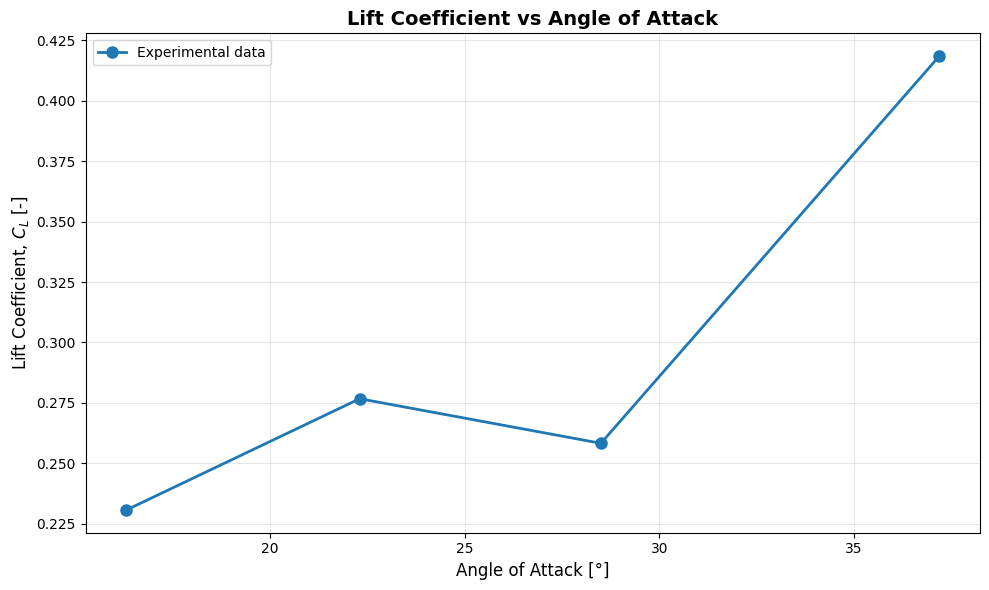

✓ Plot saved to: ../data/aerodynamic_analysis/CL_vs_alpha_experimental.png


In [118]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['alpha_deg'], df['CL'], 'o-', linewidth=2, markersize=8, label='Experimental data')
ax.set_xlabel('Angle of Attack [°]', fontsize=12)
ax.set_ylabel('Lift Coefficient, $C_L$ [-]', fontsize=12)
ax.set_title('Lift Coefficient vs Angle of Attack', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / 'CL_vs_alpha_experimental.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to: {output_dir / 'CL_vs_alpha_experimental.png'}")

## 6. Visualization: C_D vs α

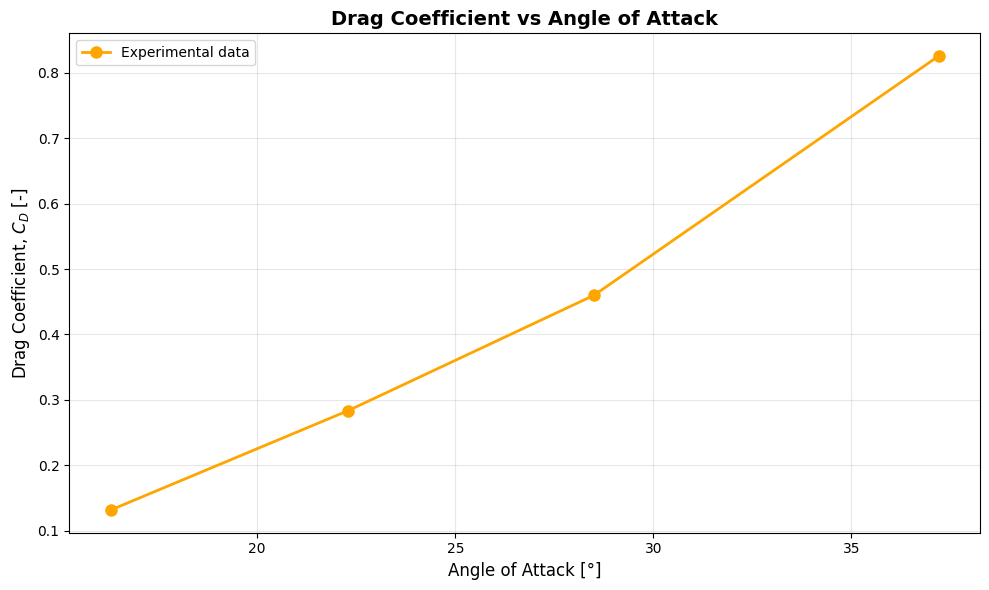

✓ Plot saved to: ../data/aerodynamic_analysis/CD_vs_alpha_experimental.png


In [119]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['alpha_deg'], df['CD'], 'o-', linewidth=2, markersize=8, color='orange', label='Experimental data')
ax.set_xlabel('Angle of Attack [°]', fontsize=12)
ax.set_ylabel('Drag Coefficient, $C_D$ [-]', fontsize=12)
ax.set_title('Drag Coefficient vs Angle of Attack', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / 'CD_vs_alpha_experimental.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to: {output_dir / 'CD_vs_alpha_experimental.png'}")

## 7. Visualization: Drag Polar (C_L vs C_D)

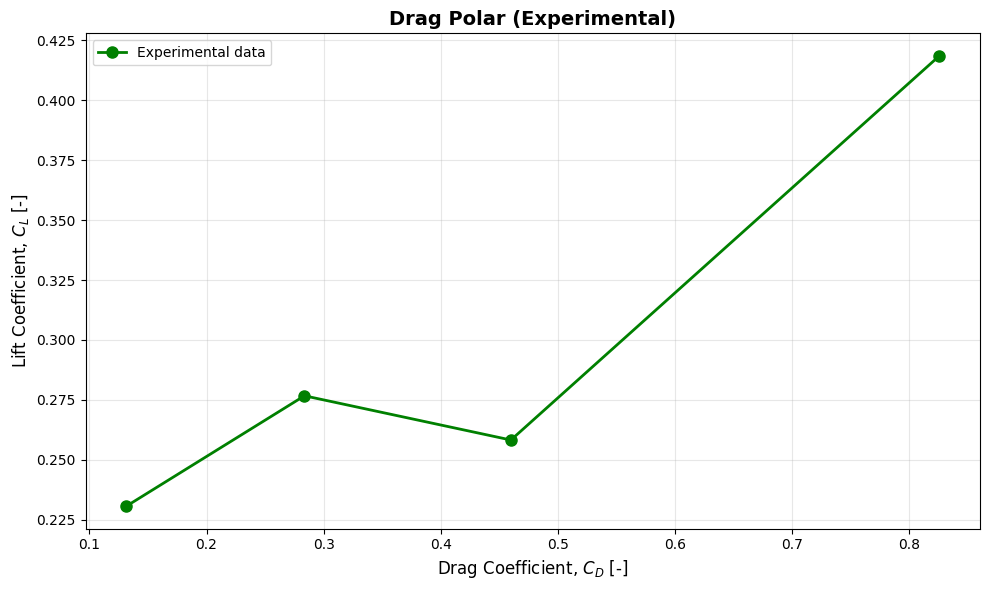

✓ Plot saved to: ../data/aerodynamic_analysis/drag_polar_experimental.png


In [120]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['CD'], df['CL'], 'o-', linewidth=2, markersize=8, color='green', label='Experimental data')
ax.set_xlabel('Drag Coefficient, $C_D$ [-]', fontsize=12)
ax.set_ylabel('Lift Coefficient, $C_L$ [-]', fontsize=12)
ax.set_title('Drag Polar (Experimental)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / 'drag_polar_experimental.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to: {output_dir / 'drag_polar_experimental.png'}")

## 8. Visualization: L/D Ratio vs Speed

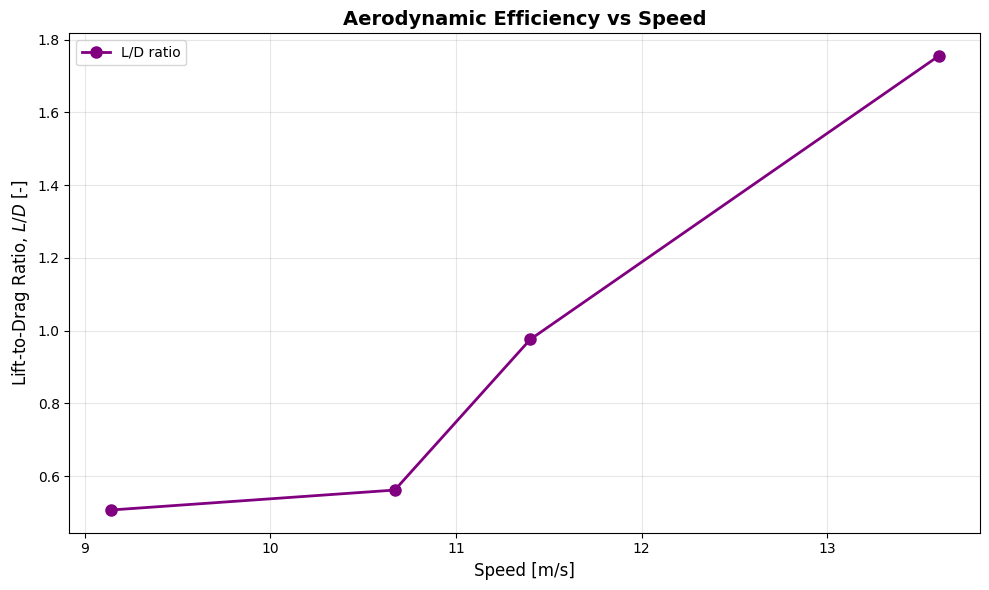

✓ Plot saved to: ../data/aerodynamic_analysis/LD_ratio_vs_speed_experimental.png


In [121]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['speed'], df['L_D_ratio'], 'o-', linewidth=2, markersize=8, color='purple', label='L/D ratio')
ax.set_xlabel('Speed [m/s]', fontsize=12)
ax.set_ylabel('Lift-to-Drag Ratio, $L/D$ [-]', fontsize=12)
ax.set_title('Aerodynamic Efficiency vs Speed', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / 'LD_ratio_vs_speed_experimental.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to: {output_dir / 'LD_ratio_vs_speed_experimental.png'}")

## 9. Visualization: Multi-Speed Comparison

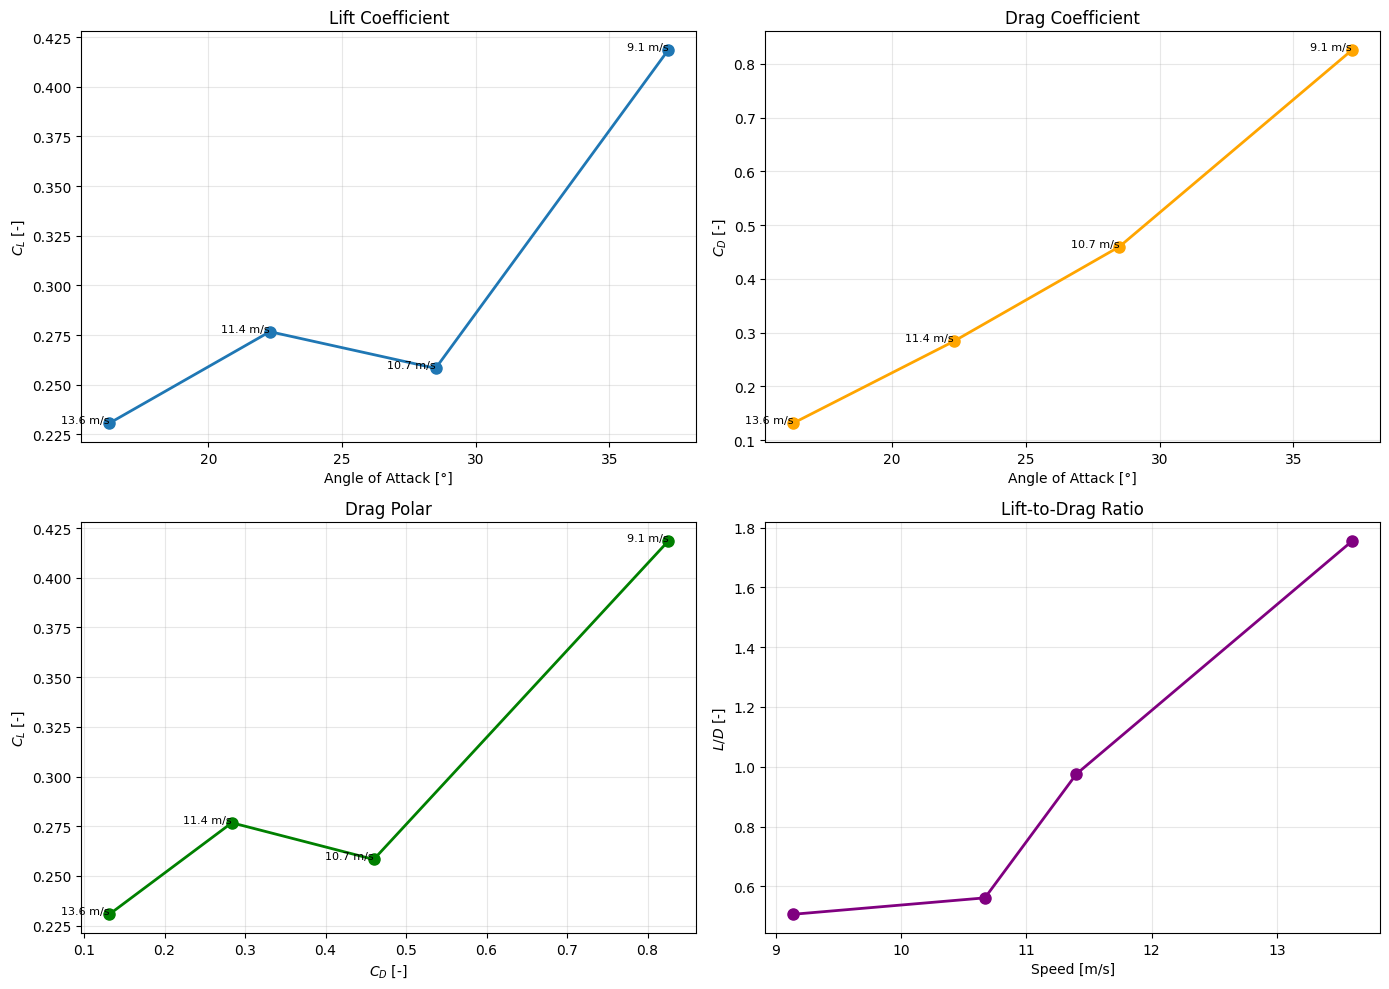

✓ Summary plot saved to: ../data/aerodynamic_analysis/aerodynamic_analysis_summary.png


In [122]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# C_L vs alpha
axes[0, 0].plot(df['alpha_deg'], df['CL'], 'o-', linewidth=2, markersize=8)
for i, row in df.iterrows():
    axes[0, 0].annotate(f"{row['speed']:.1f} m/s", 
                        (row['alpha_deg'], row['CL']), 
                        fontsize=8, ha='right')
axes[0, 0].set_xlabel('Angle of Attack [°]')
axes[0, 0].set_ylabel('$C_L$ [-]')
axes[0, 0].set_title('Lift Coefficient')
axes[0, 0].grid(True, alpha=0.3)

# C_D vs alpha
axes[0, 1].plot(df['alpha_deg'], df['CD'], 'o-', linewidth=2, markersize=8, color='orange')
for i, row in df.iterrows():
    axes[0, 1].annotate(f"{row['speed']:.1f} m/s", 
                        (row['alpha_deg'], row['CD']), 
                        fontsize=8, ha='right')
axes[0, 1].set_xlabel('Angle of Attack [°]')
axes[0, 1].set_ylabel('$C_D$ [-]')
axes[0, 1].set_title('Drag Coefficient')
axes[0, 1].grid(True, alpha=0.3)

# Drag polar
axes[1, 0].plot(df['CD'], df['CL'], 'o-', linewidth=2, markersize=8, color='green')
for i, row in df.iterrows():
    axes[1, 0].annotate(f"{row['speed']:.1f} m/s", 
                        (row['CD'], row['CL']), 
                        fontsize=8, ha='right')
axes[1, 0].set_xlabel('$C_D$ [-]')
axes[1, 0].set_ylabel('$C_L$ [-]')
axes[1, 0].set_title('Drag Polar')
axes[1, 0].grid(True, alpha=0.3)

# L/D vs speed
axes[1, 1].plot(df['speed'], df['L_D_ratio'], 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Speed [m/s]')
axes[1, 1].set_ylabel('$L/D$ [-]')
axes[1, 1].set_title('Lift-to-Drag Ratio')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'aerodynamic_analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Summary plot saved to: {output_dir / 'aerodynamic_analysis_summary.png'}")

## 10. Export Results

In [123]:
# Export full dataset
output_file = output_dir / 'experimental_aerodynamic_coefficients.csv'
df.to_csv(output_file, index=False)
print(f"✓ Full data exported to: {output_file}")

# Export summary statistics
summary = pd.DataFrame({
    'Parameter': ['Max CL', 'Min CD', 'Max L/D', 'Avg CL', 'Avg CD'],
    'Value': [
        df['CL'].max(),
        df['CD'].min(),
        df['L_D_ratio'].max(),
        df['CL'].mean(),
        df['CD'].mean()
    ]
})

summary_file = output_dir / 'aerodynamic_summary_statistics.csv'
summary.to_csv(summary_file, index=False)
print(f"✓ Summary statistics exported to: {summary_file}")

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(summary.to_string(index=False))
print("="*60)

✓ Full data exported to: ../data/aerodynamic_analysis/experimental_aerodynamic_coefficients.csv
✓ Summary statistics exported to: ../data/aerodynamic_analysis/aerodynamic_summary_statistics.csv

SUMMARY STATISTICS
Parameter    Value
   Max CL 0.418464
   Min CD 0.131484
  Max L/D 1.754615
   Avg CL 0.296050
   Avg CD 0.425175


## 11. Optional: Fit Polynomial Models

Fit polynomial models to the experimental data for use in simulations.

C_L model: C_L = 0.4743 * α + 0.0802
Lift slope: 0.4743 per radian = 27.1727 per degree

C_D model: C_D = 2.142907 * α² + -0.112252 * α + -0.006636
Minimum C_D (approx): -0.006636


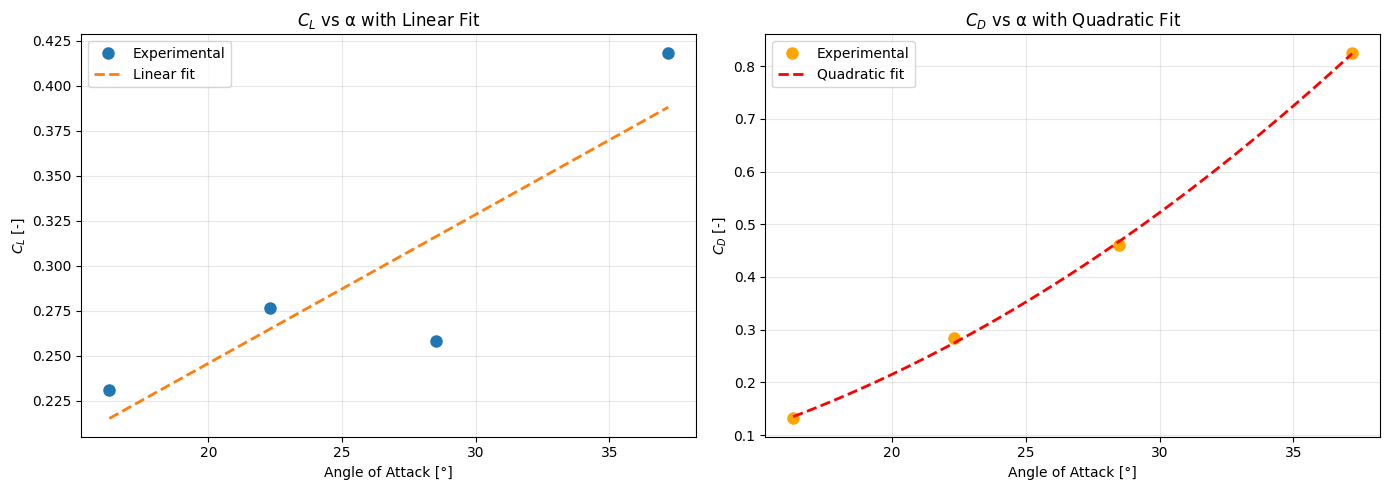


✓ Fit plots saved to: ../data/aerodynamic_analysis/coefficient_fits.png


In [124]:
# Fit C_L vs alpha (linear fit)
cl_coeffs = np.polyfit(df['alpha_rad'], df['CL'], 1)
cl_fit = np.poly1d(cl_coeffs)

print("C_L model: C_L = {:.4f} * α + {:.4f}".format(cl_coeffs[0], cl_coeffs[1]))
print(f"Lift slope: {cl_coeffs[0]:.4f} per radian = {np.rad2deg(cl_coeffs[0]):.4f} per degree")

# Fit C_D vs alpha (quadratic fit - parabolic drag polar)
cd_coeffs = np.polyfit(df['alpha_rad'], df['CD'], 2)
cd_fit = np.poly1d(cd_coeffs)

print("\nC_D model: C_D = {:.6f} * α² + {:.6f} * α + {:.6f}".format(cd_coeffs[0], cd_coeffs[1], cd_coeffs[2]))
print(f"Minimum C_D (approx): {cd_coeffs[2]:.6f}")

# Plot fits
alpha_range = np.linspace(df['alpha_rad'].min(), df['alpha_rad'].max(), 100)
alpha_range_deg = np.rad2deg(alpha_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C_L fit
axes[0].plot(df['alpha_deg'], df['CL'], 'o', markersize=8, label='Experimental')
axes[0].plot(alpha_range_deg, cl_fit(alpha_range), '--', linewidth=2, label='Linear fit')
axes[0].set_xlabel('Angle of Attack [°]')
axes[0].set_ylabel('$C_L$ [-]')
axes[0].set_title('$C_L$ vs α with Linear Fit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# C_D fit
axes[1].plot(df['alpha_deg'], df['CD'], 'o', markersize=8, color='orange', label='Experimental')
axes[1].plot(alpha_range_deg, cd_fit(alpha_range), '--', linewidth=2, color='red', label='Quadratic fit')
axes[1].set_xlabel('Angle of Attack [°]')
axes[1].set_ylabel('$C_D$ [-]')
axes[1].set_title('$C_D$ vs α with Quadratic Fit')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'coefficient_fits.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Fit plots saved to: {output_dir / 'coefficient_fits.png'}")

## Notes and Next Steps

1. **Data Quality**: Ensure steady-state flight conditions for accurate coefficient extraction
2. **Assumptions**: This analysis assumes:
   - Steady, level flight (no acceleration)
   - Negligible fuselage drag (all drag attributed to wings)
   - Accurate thrust model from motor RPM
3. **Sensitivity Analysis**: Consider uncertainty in:
   - Angle of attack measurements
   - Motor RPM readings
   - Wing area estimation
4. **Comparison**: Compare with XFLR5 predictions to validate results